# Visit 1 – Machine Learning Pipeline

Addresses reviewer comments 30-37. Drops: record_id, injury_mechanism, buckets (+ other non-predictors). Y = buckets.

In [49]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    matthews_corrcoef, brier_score_loss
)
from sklearn.model_selection import train_test_split, ParameterSampler
import warnings
warnings.filterwarnings("ignore")
print("Libraries loaded.")


Libraries loaded.


In [50]:
df = pd.read_csv("original_mech2.csv")
print(df.shape)
df.head(3)


(434, 56)


,record_id,redcap_repeat_instance,smoothpursuits_fogginess,saccades_vert_nausea,npc_fogginess,vor_vert_headache,vor_vert_nausea,bess_tandem_ec,Treatment_present,npc_dizziness,...,subocc_ext,import_gad7_score,voms_fogginess,bess_single_ec,saccades_vert_dizziness,saccades_horiz_fogginess,l_lat_flex,vor_horiz_headache,days_2_clearance,buckets
0,1,1.0,0.0,1.0,0.0,3.0,1.0,2.0,1,1.0,...,21.0,16.0,0.0,0.0,2.0,0.0,45.0,3.0,17.0,0
1,1,2.0,1.0,0.0,1.0,0.0,0.0,2.0,1,3.0,...,17.0,15.0,1.0,0.0,2.0,1.0,41.0,0.0,17.0,0
2,10,1.0,0.0,0.0,0.0,0.0,0.0,2.0,1,0.0,...,21.0,2.0,0.0,1.0,0.0,0.0,40.0,0.0,68.0,1


In [51]:
# Filters df where redcap_repeat_instace is exactly 1
# Filter and immediately reset index so the first row is always 0, second is 1, etc.
df = df[df['redcap_repeat_instance'] == 1].reset_index(drop=True)

# Access the first row safely
first_row = filtered_df.iloc[0]

In [52]:
first_row

record_id                    1.0
redcap_repeat_instance       1.0
smoothpursuits_fogginess     0.0
saccades_vert_nausea         1.0
npc_fogginess                0.0
vor_vert_headache            3.0
vor_vert_nausea              1.0
bess_tandem_ec               2.0
Treatment_present            1.0
npc_dizziness                1.0
vor_horiz_nausea             1.0
vmst_headache                3.0
injury_mechanism             2.0
smoothpursuits_nausea        1.0
r_lat_flex                  45.0
days_2_firstvisit            3.0
npc_headache                 3.0
npc_nausea                   1.0
cerv_ext                    50.0
high_total_sx_severity      40.0
bess_double_ec               0.0
voms_nausea                  1.0
saccades_horiz_nausea        1.0
prev_head_injury             0.0
cerv_flex                   60.0
vor_horiz_fogginess          0.0
hx_mood_disorder             1.0
vor_vert_dizziness           1.0
vor_horiz_dizziness          1.0
saccades_horiz_headache      3.0
npc_measur

In [53]:
print(df["buckets"].value_counts())


buckets
1    176
0     41
Name: count, dtype: int64


In [54]:
# X: explicitly drop record_id, injury_mechanism, buckets, plus other non-predictor columns
cols_X = [
    "buckets", "record_id", "injury_mechanism",
    "days_2_clearance", "days_2_firstvisit",
    "high_total_sx_severity", "redcap_repeat_instance"
]
cols_X = [c for c in cols_X if c in df.columns]

X = df.drop(columns=cols_X)
y = df["buckets"]
print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")


X shape: (217, 49)
y distribution:
buckets
1    176
0     41
Name: count, dtype: int64


## Comment 30 – EPV Reporting

In [55]:
n_total    = len(df)
n_minority = int(y.value_counts().min())
n_features = X.shape[1]
epv        = n_minority / n_features

print("=" * 50)
print(f"Total N           : {n_total}")
print(f"Minority class N  : {n_minority}")
print(f"Number of features: {n_features}")
print(f"EPV               : {epv:.2f}")
if epv < 10:
    print("WARNING: EPV < 10 – interpret results with caution (risk of overfitting).")
print("=" * 50)


Total N           : 217
Minority class N  : 41
Number of features: 49
EPV               : 0.84


## Shared Helper Functions (Comments 31, 32, 37)

In [56]:
def compute_metrics(y_true, y_pred, y_prob=None, B=1000, random_state=42):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    pts = dict(
        accuracy     = accuracy_score(y_true, y_pred),
        bal_accuracy = balanced_accuracy_score(y_true, y_pred),
        precision    = precision_score(y_true, y_pred, zero_division=0),
        recall       = recall_score(y_true, y_pred, zero_division=0),
        f1           = f1_score(y_true, y_pred, zero_division=0),
        specificity  = specificity,
        mcc          = matthews_corrcoef(y_true, y_pred),
    )
    if y_prob is not None:
        pts["brier"] = brier_score_loss(y_true, y_prob)
    rng = np.random.default_rng(random_state)
    boot = {k: [] for k in pts}
    for _ in range(B):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt, yp = y_true[idx], y_pred[idx]
        tn_b, fp_b, fn_b, tp_b = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0.0
        boot["accuracy"].append(accuracy_score(yt, yp))
        boot["bal_accuracy"].append(balanced_accuracy_score(yt, yp))
        boot["precision"].append(precision_score(yt, yp, zero_division=0))
        boot["recall"].append(recall_score(yt, yp, zero_division=0))
        boot["f1"].append(f1_score(yt, yp, zero_division=0))
        boot["specificity"].append(spec_b)
        boot["mcc"].append(matthews_corrcoef(yt, yp))
        if y_prob is not None:
            boot["brier"].append(brier_score_loss(yt, y_prob[idx]))
    cis = {k: (np.percentile(v, 2.5), np.percentile(v, 97.5)) for k, v in boot.items()}
    print("Metric               Point Est   95% CI")
    print("-" * 48)
    for k, val in pts.items():
        lo, hi = cis[k]
        print(f"{k:<20} {val:.4f}      [{lo:.4f}, {hi:.4f}]")
    return pts, cis

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_feature_importance(fi_df, title="Top 20 Feature Importances"):
    top20 = fi_df.head(20).copy()
    plt.figure(figsize=(8, 6))
    plt.barh(top20["feature"][::-1], top20["importance"][::-1], color="steelblue")
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return top20

def plot_effect_direction(model, X, top20, title="Average Effect"):
    top_feats = top20["feature"].tolist()
    effects = []
    for f in top_feats:
        med = X[f].median()
        X_hi = X[X[f] > med]
        X_lo = X[X[f] <= med]
        ph = model.predict_proba(X_hi)[:, 1].mean() if not X_hi.empty else 0.0
        pl = model.predict_proba(X_lo)[:, 1].mean() if not X_lo.empty else 0.0
        effects.append({"feature": f, "avg_effect": ph - pl})
    eff_df = pd.DataFrame(effects).sort_values("avg_effect", key=abs, ascending=False)
    colors = eff_df["avg_effect"].apply(lambda v: "red" if v > 0 else "blue")
    plt.figure(figsize=(8, 6))
    plt.barh(eff_df["feature"], eff_df["avg_effect"], color=colors)
    plt.xlabel("Avg Effect on P(prolonged recovery)")
    plt.axvline(0, color="black", lw=0.8)
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    return eff_df

print("Helper functions ready.")


Helper functions ready.


## LightGBM

In [57]:
import lightgbm as lgb

X_lgbm = df.drop(columns=cols_X)
y_lgbm = df["buckets"]

X_tr, X_te, y_tr, y_te = train_test_split(X_lgbm, y_lgbm, test_size=0.2, random_state=42)

param_dist = {
    "num_leaves":        [31, 50, 70],
    "max_depth":         [-1, 10, 20, 30],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "n_estimators":      [100, 200, 500, 1000],
    "min_child_samples": [10, 20, 30, 50],
    "subsample":         [0.6, 0.8, 1.0],
    "colsample_bytree":  [0.6, 0.8, 1.0],
}
param_list = list(ParameterSampler(param_dist, n_iter=50, random_state=42))

best_score_lgbm, best_params_lgbm = 0, None
for params in param_list:
    m = lgb.LGBMClassifier(random_state=42, verbose=-1, **params)
    m.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_lgbm:
        best_score_lgbm = acc
        best_params_lgbm = params

print("Best params:", best_params_lgbm)
print(f"Best balanced accuracy (hold-out): {best_score_lgbm:.4f}")


Best params: {'subsample': 0.8, 'num_leaves': 50, 'n_estimators': 1000, 'min_child_samples': 10, 'max_depth': 20, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
Best balanced accuracy (hold-out): 0.8864


In [58]:
y_true_lgbm, y_pred_lgbm, y_prob_lgbm = [], [], []
fi_sum_lgbm = np.zeros(X_lgbm.shape[1])

for i in range(len(df)):
    Xtr = X_lgbm.drop(index=i)
    ytr = y_lgbm.drop(index=i)
    Xte = X_lgbm.iloc[[i]]
    m = lgb.LGBMClassifier(random_state=42,                             verbose=-1, **best_params_lgbm)
    m.fit(Xtr, ytr)
    fi_sum_lgbm += m.booster_.feature_importance(importance_type="gain")
    y_pred_lgbm.append(m.predict(Xte)[0])
    y_prob_lgbm.append(m.predict_proba(Xte)[0, 1])
    y_true_lgbm.append(y_lgbm.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")

y_true_lgbm = np.array(y_true_lgbm)
y_pred_lgbm = np.array(y_pred_lgbm)
y_prob_lgbm = np.array(y_prob_lgbm)
print("=== LightGBM LOOCV Results (Visit 1) ===")
metrics_lgbm, cis_lgbm = compute_metrics(y_true_lgbm, y_pred_lgbm, y_prob_lgbm)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== LightGBM LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.8157      [0.7650, 0.8664]
bal_accuracy         0.5683      [0.5104, 0.6326]
precision            0.8333      [0.7767, 0.8824]
recall               0.9659      [0.9364, 0.9889]
f1                   0.8947      [0.8594, 0.9254]
specificity          0.1707      [0.0541, 0.2942]
mcc                  0.2254      [0.0414, 0.3913]
brier                0.1644      [0.1224, 0.2134]


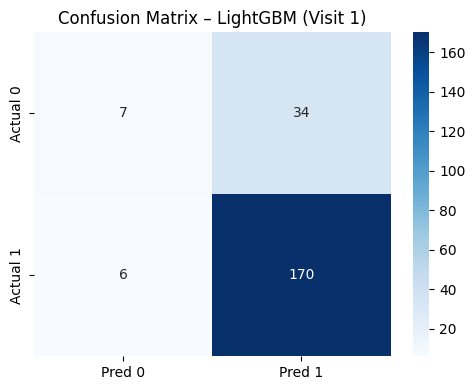

=== Top 20 Features – LightGBM ===
                 feature  importance
              l_cerv_rot   57.595506
               cerv_flex   56.790247
       Treatment_present   55.322318
              l_lat_flex   40.903097
       import_phq9_score   38.490526
              r_cerv_rot   34.990206
             subocc_flex   33.768882
                cerv_ext   28.560324
       import_gad7_score   24.392871
      vor_vert_dizziness   21.353734
             npc_measure   20.512385
          bess_single_ec   19.023656
              r_lat_flex   15.942026
              subocc_ext   15.349779
     vor_horiz_dizziness   14.002350
smoothpursuits_fogginess   10.155206
       vor_vert_headache    8.292905
          bess_tandem_ec    7.449845
 smoothpursuits_headache    7.358110
           vmst_headache    7.349358


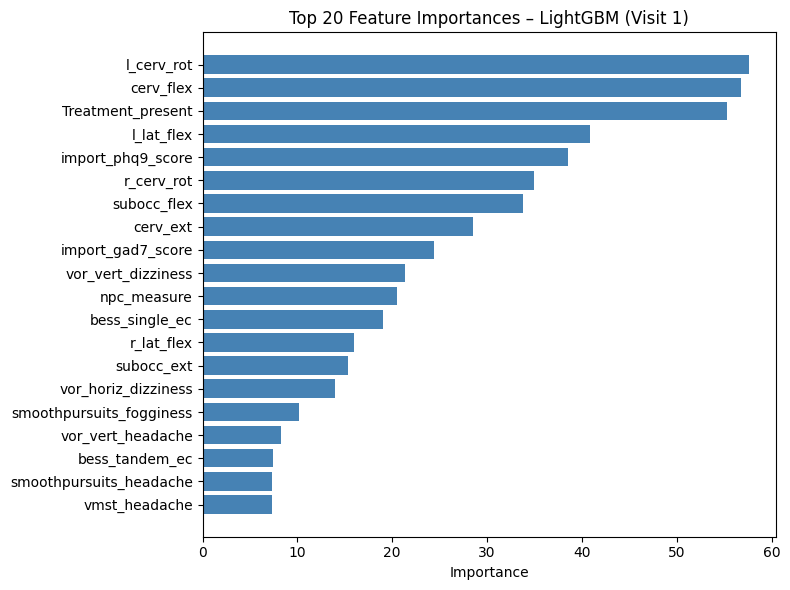

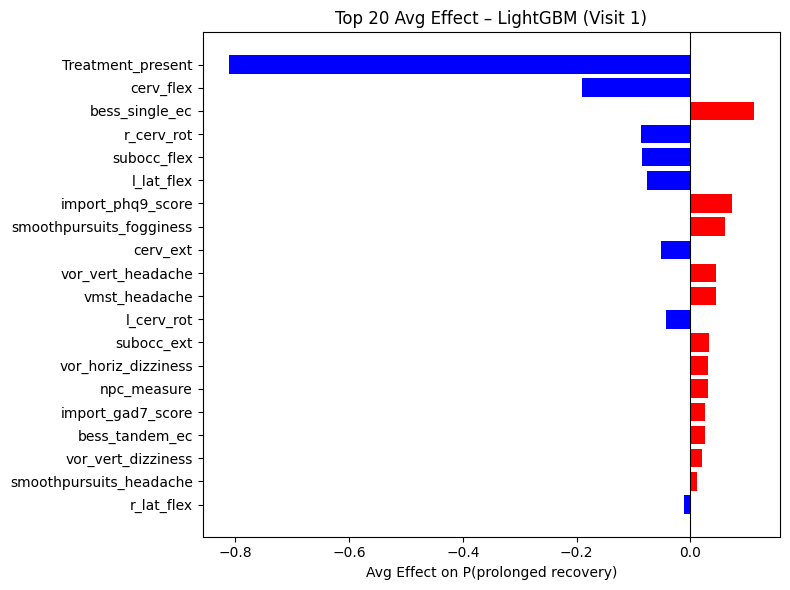

,feature,avg_effect
2,Treatment_present,-0.811060
1,cerv_flex,-0.191116
11,bess_single_ec,0.111167
5,r_cerv_rot,-0.087114
6,subocc_flex,-0.084692
3,l_lat_flex,-0.076786
4,import_phq9_score,0.072221
15,smoothpursuits_fogginess,0.060440
7,cerv_ext,-0.051316
16,vor_vert_headache,0.044957


In [59]:
plot_confusion(y_true_lgbm, y_pred_lgbm, "Confusion Matrix – LightGBM (Visit 1)")
fi_df_lgbm = (pd.DataFrame({"feature": X_lgbm.columns, "importance": fi_sum_lgbm / len(df)})
              .sort_values("importance", ascending=False))
print("=== Top 20 Features – LightGBM ===")
print(fi_df_lgbm.head(20).to_string(index=False))
top20_lgbm = plot_feature_importance(fi_df_lgbm, "Top 20 Feature Importances – LightGBM (Visit 1)")
_m_lgbm = lgb.LGBMClassifier(random_state=42,                                verbose=-1, **best_params_lgbm).fit(X_lgbm, y_lgbm)
plot_effect_direction(_m_lgbm, X_lgbm, top20_lgbm, "Top 20 Avg Effect – LightGBM (Visit 1)")


## Decision Tree

In [60]:
from sklearn.tree import DecisionTreeClassifier

X_dt = df.drop(columns=cols_X)
y_dt = df["buckets"]

X_tr, X_te, y_tr, y_te = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42)
param_dist_dt = {
    "criterion":        ["gini", "entropy", "log_loss"],
    "max_depth":        [None, 10, 20, 30, 50],
    "min_samples_split":[2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features":     [None, "sqrt", "log2"],
    "splitter":         ["best", "random"],
}
param_list_dt = list(ParameterSampler(param_dist_dt, n_iter=50, random_state=42))

best_score_dt, best_params_dt = 0, None
for params in param_list_dt:
    m = DecisionTreeClassifier(random_state=42, **params)
    m.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_dt:
        best_score_dt = acc
        best_params_dt = params

print("Best params:", best_params_dt)
print(f"Best balanced accuracy: {best_score_dt:.4f}")


Best params: {'splitter': 'random', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'log_loss'}
Best balanced accuracy: 0.9091


In [61]:
y_true_dt, y_pred_dt, y_prob_dt = [], [], []
fi_sum_dt = np.zeros(X_dt.shape[1])
for i in range(len(df)):
    Xtr = X_dt.drop(index=i)
    ytr = y_dt.drop(index=i)
    Xte = X_dt.iloc[[i]]
    m = DecisionTreeClassifier(random_state=42, **best_params_dt)
    m.fit(Xtr, ytr)
    fi_sum_dt += m.feature_importances_
    y_pred_dt.append(m.predict(Xte)[0])
    y_prob_dt.append(m.predict_proba(Xte)[0, 1])
    y_true_dt.append(y_dt.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_dt, y_pred_dt, y_prob_dt = np.array(y_true_dt), np.array(y_pred_dt), np.array(y_prob_dt)
print("=== Decision Tree LOOCV Results (Visit 1) ===")
metrics_dt, cis_dt = compute_metrics(y_true_dt, y_pred_dt, y_prob_dt)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== Decision Tree LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.7742      [0.7097, 0.8250]
bal_accuracy         0.6082      [0.5327, 0.6843]
precision            0.8508      [0.7921, 0.9011]
recall               0.8750      [0.8232, 0.9182]
f1                   0.8627      [0.8190, 0.8975]
specificity          0.3415      [0.1944, 0.4884]
mcc                  0.2278      [0.0704, 0.3778]
brier                0.1738      [0.1366, 0.2135]


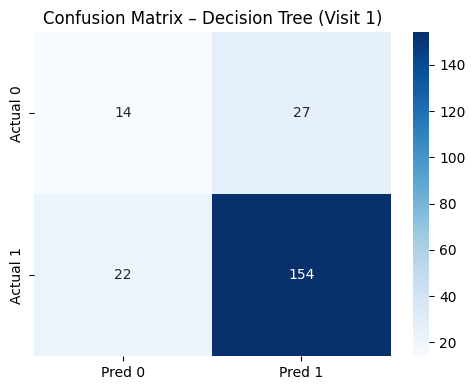

=== Top 20 Features – Decision Tree ===
                 feature  importance
       Treatment_present    0.264359
      vor_vert_dizziness    0.090804
          bess_single_ec    0.075030
            npc_headache    0.045158
          voms_dizziness    0.042587
           vmst_headache    0.042068
             npc_measure    0.038906
   saccades_horiz_nausea    0.031918
          vmst_dizziness    0.031409
smoothpursuits_fogginess    0.029333
           npc_fogginess    0.029318
             vmst_nausea    0.028671
        hx_mood_disorder    0.027999
         vor_vert_nausea    0.027948
                cerv_ext    0.022367
     vor_horiz_dizziness    0.022270
saccades_horiz_dizziness    0.022217
smoothpursuits_dizziness    0.018863
           voms_headache    0.016464
       import_phq9_score    0.016249


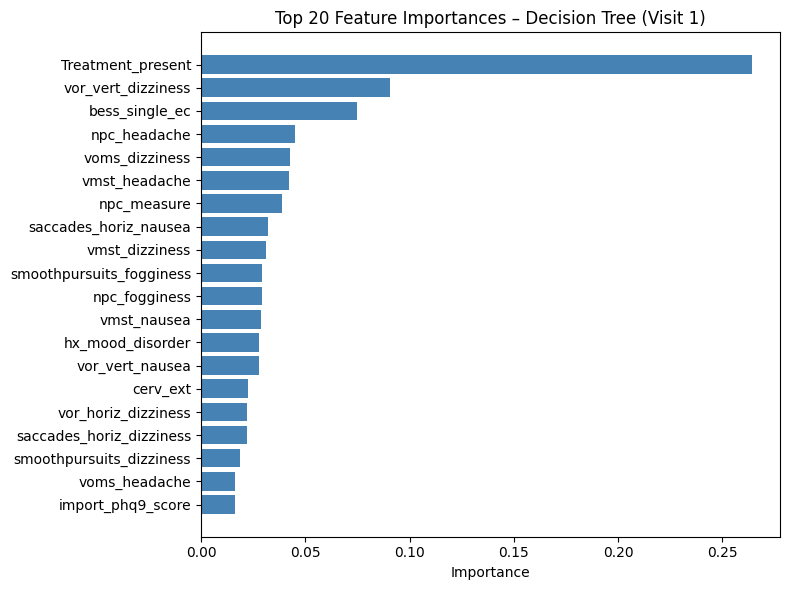

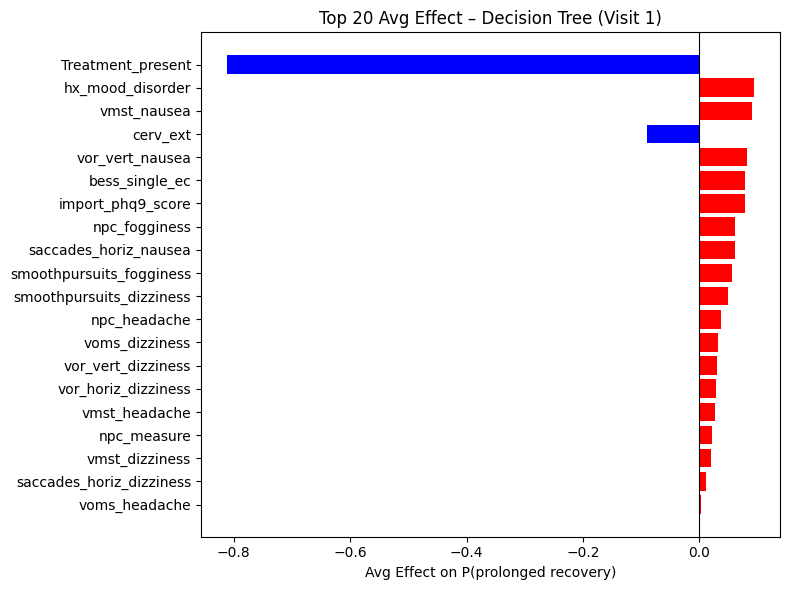

,feature,avg_effect
0,Treatment_present,-0.811060
12,hx_mood_disorder,0.093474
11,vmst_nausea,0.091254
14,cerv_ext,-0.089203
13,vor_vert_nausea,0.081526
2,bess_single_ec,0.079268
19,import_phq9_score,0.077970
10,npc_fogginess,0.062193
7,saccades_horiz_nausea,0.060622
9,smoothpursuits_fogginess,0.055400


In [62]:
plot_confusion(y_true_dt, y_pred_dt, "Confusion Matrix – Decision Tree (Visit 1)")
fi_df_dt = (pd.DataFrame({"feature": X_dt.columns, "importance": fi_sum_dt / len(df)})
             .sort_values("importance", ascending=False))
print("=== Top 20 Features – Decision Tree ===")
print(fi_df_dt.head(20).to_string(index=False))
top20_dt = plot_feature_importance(fi_df_dt, "Top 20 Feature Importances – Decision Tree (Visit 1)")
_m_dt = DecisionTreeClassifier(random_state=42, **best_params_dt).fit(X_dt, y_dt)
plot_effect_direction(_m_dt, X_dt, top20_dt, "Top 20 Avg Effect – Decision Tree (Visit 1)")


## Random Forest

In [63]:
from sklearn.ensemble import RandomForestClassifier

X_rf = df.drop(columns=cols_X)
y_rf = df["buckets"]
X_tr, X_te, y_tr, y_te = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

param_dist_rf = {
    "criterion":        ["gini", "entropy"],
    "max_depth":        [None, 10, 20, 30, 50],
    "min_samples_split":[2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features":     [None, "sqrt", "log2"],
}
param_list_rf = list(ParameterSampler(param_dist_rf, n_iter=50, random_state=42))
best_score_rf, best_params_rf = 0, None
for params in param_list_rf:
    m = RandomForestClassifier(random_state=42, **params)
    m.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_rf:
        best_score_rf = acc
        best_params_rf = params
print("Best params:", best_params_rf)
print(f"Best balanced accuracy: {best_score_rf:.4f}")


Best params: {'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'gini'}
Best balanced accuracy: 0.8182


In [64]:
y_true_rf, y_pred_rf, y_prob_rf = [], [], []
fi_sum_rf = np.zeros(X_rf.shape[1])
for i in range(len(df)):
    Xtr = X_rf.drop(index=i)
    ytr = y_rf.drop(index=i)
    Xte = X_rf.iloc[[i]]
    m = RandomForestClassifier(random_state=42, **best_params_rf)
    m.fit(Xtr, ytr)
    fi_sum_rf += m.feature_importances_
    y_pred_rf.append(m.predict(Xte)[0])
    y_prob_rf.append(m.predict_proba(Xte)[0, 1])
    y_true_rf.append(y_rf.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_rf, y_pred_rf, y_prob_rf = np.array(y_true_rf), np.array(y_pred_rf), np.array(y_prob_rf)
print("=== Random Forest LOOCV Results (Visit 1) ===")
metrics_rf, cis_rf = compute_metrics(y_true_rf, y_pred_rf, y_prob_rf)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== Random Forest LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.8111      [0.7558, 0.8618]
bal_accuracy         0.5000      [0.5000, 0.5000]
precision            0.8111      [0.7558, 0.8618]
recall               1.0000      [1.0000, 1.0000]
f1                   0.8957      [0.8609, 0.9257]
specificity          0.0000      [0.0000, 0.0000]
mcc                  0.0000      [0.0000, 0.0000]
brier                0.1474      [0.1188, 0.1795]


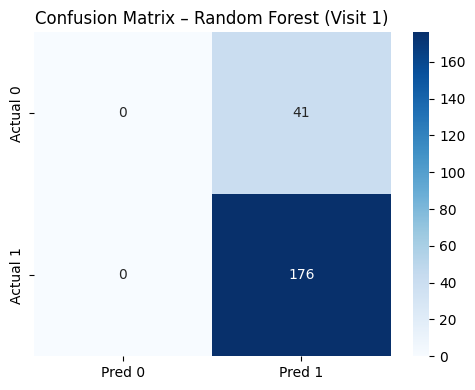

=== Top 20 Features – Random Forest ===
               feature  importance
             cerv_flex    0.093019
            l_cerv_rot    0.084704
     Treatment_present    0.079587
            r_cerv_rot    0.059525
     import_phq9_score    0.052549
     import_gad7_score    0.043975
            l_lat_flex    0.040244
        bess_single_ec    0.036919
            subocc_ext    0.036841
              cerv_ext    0.032880
           subocc_flex    0.031311
            r_lat_flex    0.029555
           npc_measure    0.028548
        vmst_dizziness    0.020838
   vor_horiz_dizziness    0.020832
         vmst_headache    0.016289
    vor_horiz_headache    0.016110
saccades_vert_headache    0.015905
    vor_vert_dizziness    0.015767
        bess_tandem_ec    0.015186


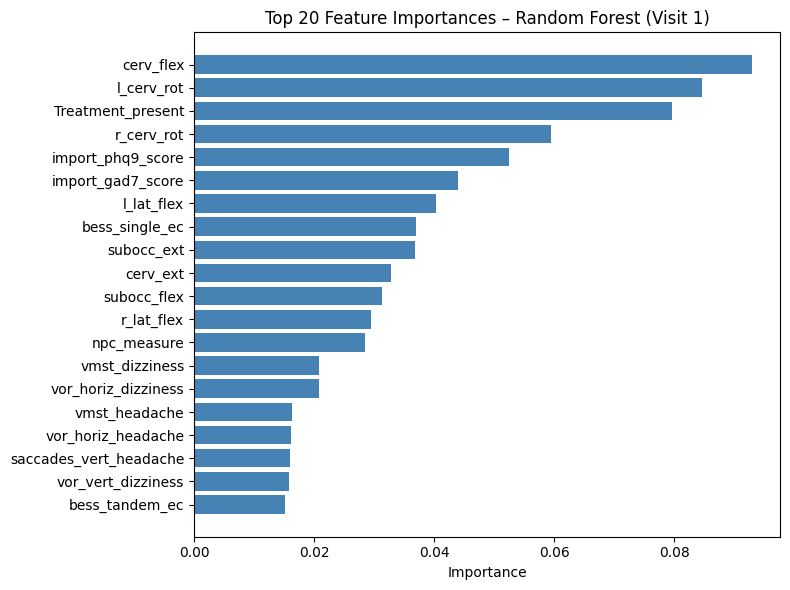

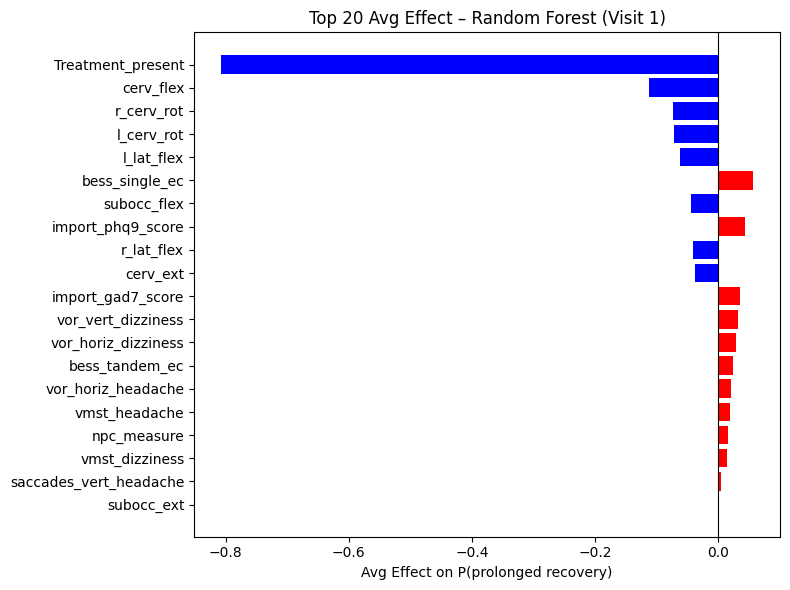

,feature,avg_effect
2,Treatment_present,-0.807927
0,cerv_flex,-0.112237
3,r_cerv_rot,-0.073875
1,l_cerv_rot,-0.071664
6,l_lat_flex,-0.062958
7,bess_single_ec,0.056736
10,subocc_flex,-0.044801
4,import_phq9_score,0.043512
11,r_lat_flex,-0.040978
9,cerv_ext,-0.038251


In [65]:
plot_confusion(y_true_rf, y_pred_rf, "Confusion Matrix – Random Forest (Visit 1)")
fi_df_rf = (pd.DataFrame({"feature": X_rf.columns, "importance": fi_sum_rf / len(df)})
             .sort_values("importance", ascending=False))
print("=== Top 20 Features – Random Forest ===")
print(fi_df_rf.head(20).to_string(index=False))
top20_rf = plot_feature_importance(fi_df_rf, "Top 20 Feature Importances – Random Forest (Visit 1)")
_m_rf = RandomForestClassifier(random_state=42, **best_params_rf).fit(X_rf, y_rf)
plot_effect_direction(_m_rf, X_rf, top20_rf, "Top 20 Avg Effect – Random Forest (Visit 1)")


## XGBoost

In [66]:
from xgboost import XGBClassifier

X_xgb = df.drop(columns=cols_X)
y_xgb = df["buckets"]
X_tr, X_te, y_tr, y_te = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

param_dist_xgb = {
    "max_depth":        [3, 5, 7],
    "learning_rate":    [0.05, 0.1, 0.2],
    "subsample":        [0.7, 0.85, 1.0],
    "n_estimators":     [50, 100, 150],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "gamma":            [0, 0.1, 0.3],
    "min_child_weight": [1, 3, 5],
    "reg_alpha":        [0, 0.1, 0.5],
    "reg_lambda":       [0.5, 1.0, 1.5],
}
param_list_xgb = list(ParameterSampler(param_dist_xgb, n_iter=50, random_state=42))
best_score_xgb, best_params_xgb = 0, None
for params in param_list_xgb:
    m = XGBClassifier(random_state=42,
                      eval_metric="logloss", verbosity=0, **params)
    m.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_xgb:
        best_score_xgb = acc
        best_params_xgb = params
print("Best params:", best_params_xgb)
print(f"Best balanced accuracy: {best_score_xgb:.4f}")


Best params: {'subsample': 0.85, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
Best balanced accuracy: 0.8636


In [67]:
y_true_xgb, y_pred_xgb, y_prob_xgb = [], [], []
importance_accum_xgb = pd.DataFrame(0.0, index=X_xgb.columns, columns=["importance"])
for i in range(len(df)):
    Xtr = X_xgb.drop(index=i)
    ytr = y_xgb.drop(index=i)
    Xte = X_xgb.iloc[[i]]
    m = XGBClassifier(random_state=42,
                      eval_metric="logloss", verbosity=0, **best_params_xgb)
    m.fit(Xtr, ytr)
    fold_imp = m.get_booster().get_score(importance_type="gain")
    for feat, score in fold_imp.items():
        if feat in importance_accum_xgb.index:
            importance_accum_xgb.loc[feat, "importance"] += score
    y_pred_xgb.append(m.predict(Xte)[0])
    y_prob_xgb.append(m.predict_proba(Xte)[0, 1])
    y_true_xgb.append(y_xgb.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_xgb, y_pred_xgb, y_prob_xgb = np.array(y_true_xgb), np.array(y_pred_xgb), np.array(y_prob_xgb)
print("=== XGBoost LOOCV Results (Visit 1) ===")
metrics_xgb, cis_xgb = compute_metrics(y_true_xgb, y_pred_xgb, y_prob_xgb)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== XGBoost LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.8203      [0.7650, 0.8710]
bal_accuracy         0.5805      [0.5211, 0.6451]
precision            0.8374      [0.7811, 0.8867]
recall               0.9659      [0.9360, 0.9888]
f1                   0.8971      [0.8595, 0.9278]
specificity          0.1951      [0.0769, 0.3208]
mcc                  0.2566      [0.0756, 0.4219]
brier                0.1510      [0.1160, 0.1917]


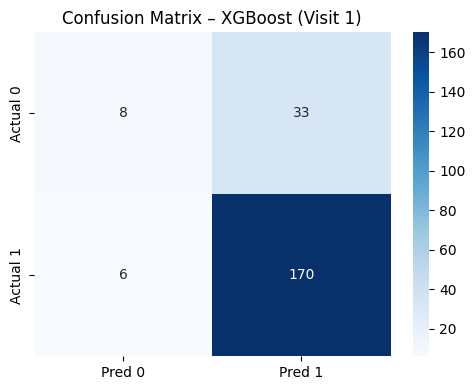

=== Top 20 Features – XGBoost ===
                 feature  importance
smoothpursuits_fogginess         0.0
             npc_measure         0.0
          vmst_dizziness         0.0
 smoothpursuits_headache         0.0
           voms_headache         0.0
             subocc_flex         0.0
              r_cerv_rot         0.0
smoothpursuits_dizziness         0.0
             vmst_nausea         0.0
 saccades_vert_fogginess         0.0
              l_cerv_rot         0.0
       import_phq9_score         0.0
          voms_dizziness         0.0
saccades_horiz_dizziness         0.0
  saccades_vert_headache         0.0
          vmst_fogginess         0.0
              subocc_ext         0.0
       import_gad7_score         0.0
          voms_fogginess         0.0
          bess_single_ec         0.0


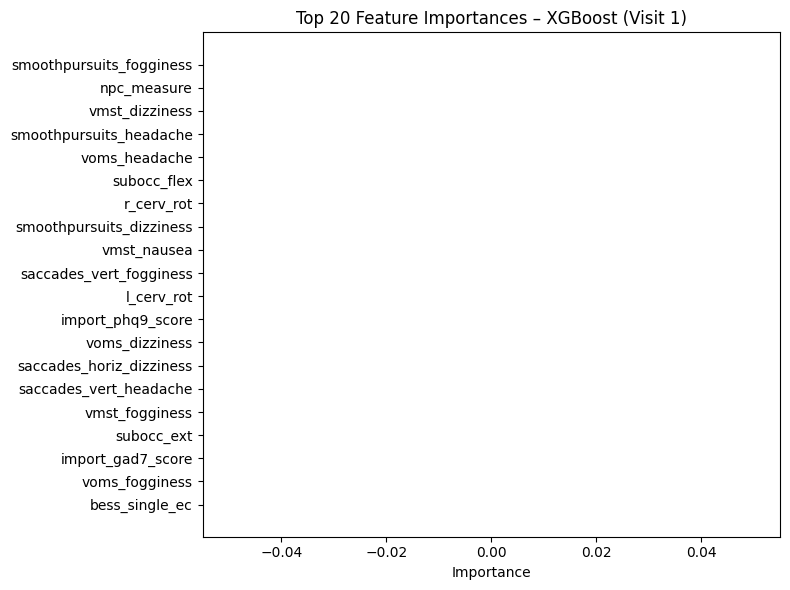

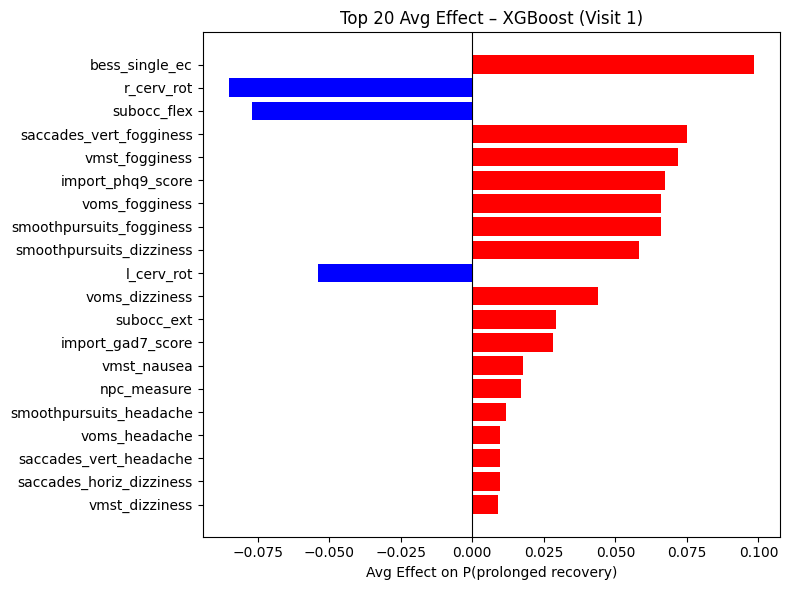

,feature,avg_effect
19,bess_single_ec,0.098357
6,r_cerv_rot,-0.085086
5,subocc_flex,-0.077137
9,saccades_vert_fogginess,0.074957
15,vmst_fogginess,0.071764
11,import_phq9_score,0.067322
18,voms_fogginess,0.065836
0,smoothpursuits_fogginess,0.065836
7,smoothpursuits_dizziness,0.058084
10,l_cerv_rot,-0.053791


In [68]:
plot_confusion(y_true_xgb, y_pred_xgb, "Confusion Matrix – XGBoost (Visit 1)")
importance_accum_xgb["importance"] /= len(df)
fi_df_xgb = (importance_accum_xgb.reset_index().rename(columns={"index": "feature"})
              .sort_values("importance", ascending=False))
print("=== Top 20 Features – XGBoost ===")
print(fi_df_xgb.head(20).to_string(index=False))
top20_xgb = plot_feature_importance(fi_df_xgb, "Top 20 Feature Importances – XGBoost (Visit 1)")
_m_xgb = XGBClassifier(random_state=42,
                        eval_metric="logloss", verbosity=0, **best_params_xgb).fit(X_xgb, y_xgb)
plot_effect_direction(_m_xgb, X_xgb, top20_xgb, "Top 20 Avg Effect – XGBoost (Visit 1)")


In [69]:
y_true_xgb, y_pred_xgb, y_prob_xgb = [], [], []
importance_accum_xgb = pd.DataFrame(0.0, index=X_xgb.columns, columns=["importance"])

# Specify importance_type in the constructor to ensure 'gain' is used
_xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss", 
    verbosity=0, 
    importance_type="gain", # Explicitly set importance type
    **best_params_xgb
)

X_xgb = X_xgb.reset_index(drop=True)
y_xgb = y_xgb.reset_index(drop=True)

for i in range(len(df)):
    Xtr = X_xgb.drop(i)
    ytr = y_xgb.drop(i)
    Xte = X_xgb.iloc[[i]]

    _xgb_model.fit(Xtr, ytr)

    # FIX: Use feature_importances_ which aligns with X_xgb.columns
    importance_accum_xgb["importance"] += _xgb_model.feature_importances_

    y_pred_xgb.append(_xgb_model.predict(Xte)[0])
    y_prob_xgb.append(_xgb_model.predict_proba(Xte)[0, 1])
    y_true_xgb.append(y_xgb.iloc[i])

    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")

y_true_xgb, y_pred_xgb, y_prob_xgb = np.array(y_true_xgb), np.array(y_pred_xgb), np.array(y_prob_xgb)

# Calculate average importance and sort
importance_accum_xgb["importance"] /= len(df)
importance_table = importance_accum_xgb.sort_values(by="importance", ascending=False)

print("=== XGBoost LOOCV Results (Visit 1) ===")
metrics_xgb, cis_xgb = compute_metrics(y_true_xgb, y_pred_xgb, y_prob_xgb)

print("\n=== XGBoost Feature Importance (Average Gain) ===")
importance_table.head(20)

Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== XGBoost LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.8203      [0.7650, 0.8710]
bal_accuracy         0.5805      [0.5211, 0.6451]
precision            0.8374      [0.7811, 0.8867]
recall               0.9659      [0.9360, 0.9888]
f1                   0.8971      [0.8595, 0.9278]
specificity          0.1951      [0.0769, 0.3208]
mcc                  0.2566      [0.0756, 0.4219]
brier                0.1510      [0.1160, 0.1917]

=== XGBoost Feature Importance (Average Gain) ===


,importance
Treatment_present,0.067855
prev_head_injury,0.043828
saccades_horiz_headache,0.043427
voms_headache,0.033987
l_cerv_rot,0.033330
npc_measure,0.032182
bess_single_ec,0.031475
cerv_flex,0.030977
r_cerv_rot,0.028621
vor_horiz_dizziness,0.026762


## SVC

In [70]:
from sklearn.svm import SVC

X_svc = df.drop(columns=cols_X)
y_svc = df["buckets"]
X_tr, X_te, y_tr, y_te = train_test_split(X_svc, y_svc, test_size=0.2, random_state=42)

param_dist_svc = {
    "C":      [0.1, 1, 10, 100],
    "gamma":  [1, 0.1, 0.01, 0.0001],
    "kernel": ["linear", "rbf", "poly"],
}
param_list_svc = list(ParameterSampler(param_dist_svc, n_iter=50, random_state=42))
best_score_svc, best_params_svc = 0, None
for params in param_list_svc:
    m = SVC(random_state=42, **params)
    m.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_svc:
        best_score_svc = acc
        best_params_svc = params
print("Best params:", best_params_svc)
print(f"Best balanced accuracy: {best_score_svc:.4f}")


Best params: {'kernel': 'linear', 'gamma': 1, 'C': 0.1}
Best balanced accuracy: 0.8182


In [71]:
y_true_svc, y_pred_svc, y_prob_svc = [], [], []
fi_sum_svc = np.zeros(X_svc.shape[1])
for i in range(len(df)):
    Xtr = X_svc.drop(index=i)
    ytr = y_svc.drop(index=i)
    Xte = X_svc.iloc[[i]]
    m = SVC(random_state=42, probability=True, **best_params_svc)
    m.fit(Xtr, ytr)
    if best_params_svc.get("kernel") == "linear":
        fi_sum_svc += np.abs(m.coef_).flatten()
    y_pred_svc.append(m.predict(Xte)[0])
    y_prob_svc.append(m.predict_proba(Xte)[0, 1])
    y_true_svc.append(y_svc.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_svc, y_pred_svc, y_prob_svc = np.array(y_true_svc), np.array(y_pred_svc), np.array(y_prob_svc)
print("=== SVC LOOCV Results (Visit 1) ===")
metrics_svc, cis_svc = compute_metrics(y_true_svc, y_pred_svc, y_prob_svc)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== SVC LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.8065      [0.7512, 0.8571]
bal_accuracy         0.4972      [0.4910, 0.5000]
precision            0.8102      [0.7546, 0.8611]
recall               0.9943      [0.9819, 1.0000]
f1                   0.8929      [0.8579, 0.9231]
specificity          0.0000      [0.0000, 0.0000]
mcc                  -0.0328      [-0.0621, 0.0000]
brier                0.1565      [0.1248, 0.1921]


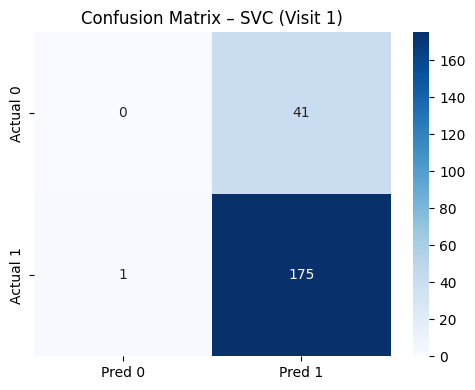

=== Top 20 Features – SVC ===
                 feature  importance
       Treatment_present    0.356968
              npc_nausea    0.234647
          voms_fogginess    0.160472
    saccades_vert_nausea    0.146265
 saccades_vert_dizziness    0.121268
   smoothpursuits_nausea    0.119212
smoothpursuits_dizziness    0.101312
saccades_horiz_dizziness    0.095615
      vor_vert_dizziness    0.095547
           vmst_headache    0.093134
     vor_horiz_dizziness    0.091163
          voms_dizziness    0.074287
saccades_horiz_fogginess    0.064369
          bess_double_ec    0.063497
           npc_dizziness    0.060964
          vmst_dizziness    0.046261
smoothpursuits_fogginess    0.039304
        hx_mood_disorder    0.038886
        prev_head_injury    0.038139
           voms_headache    0.037376


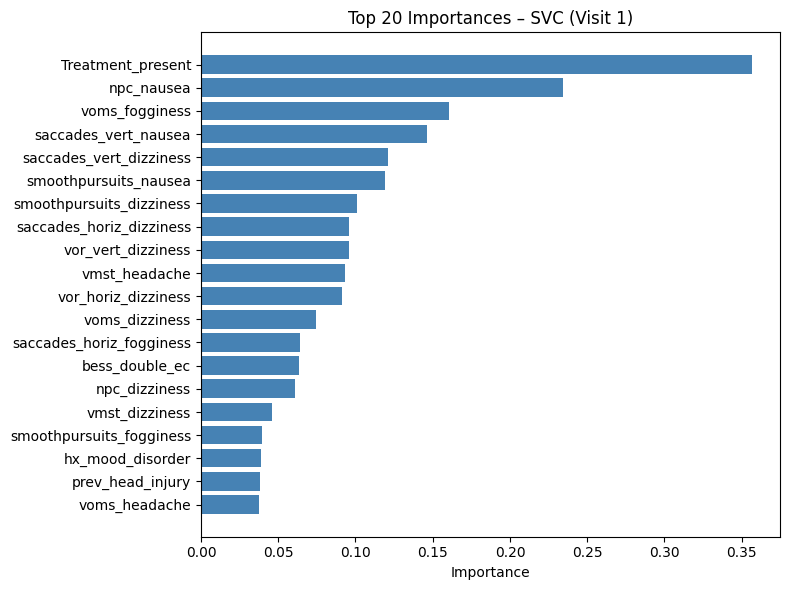

In [72]:
plot_confusion(y_true_svc, y_pred_svc, "Confusion Matrix – SVC (Visit 1)")
if best_params_svc.get("kernel") == "linear":
    fi_df_svc = (pd.DataFrame({"feature": X_svc.columns, "importance": fi_sum_svc / len(df)})
                 .sort_values("importance", ascending=False))
else:
    from sklearn.inspection import permutation_importance as perm_imp
    _m_svc = SVC(random_state=42, probability=True,
                 **best_params_svc).fit(X_svc, y_svc)
    perm = perm_imp(_m_svc, X_svc, y_svc, scoring="accuracy",
                    n_repeats=20, random_state=42, n_jobs=-1)
    fi_df_svc = (pd.DataFrame({"feature": X_svc.columns, "importance": perm.importances_mean})
                 .sort_values("importance", ascending=False))
print("=== Top 20 Features – SVC ===")
print(fi_df_svc.head(20).to_string(index=False))
top20_svc = plot_feature_importance(fi_df_svc, "Top 20 Importances – SVC (Visit 1)")


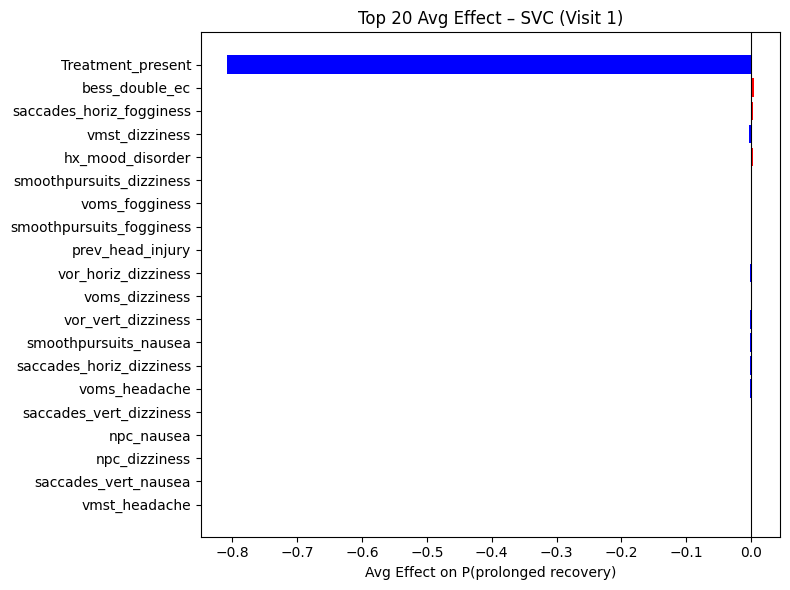

In [73]:
# Average effect plot – SVC
# Uses predict_proba (probability=True was set during LOOCV)
_m_svc = SVC(random_state=42, probability=True,
             **best_params_svc).fit(X_svc, y_svc)

top_feats_svc = top20_svc["feature"].tolist()
effects_svc = []
for f in top_feats_svc:
    med = X_svc[f].median()
    X_hi = X_svc[X_svc[f] > med]
    X_lo = X_svc[X_svc[f] <= med]
    ph = _m_svc.predict_proba(X_hi)[:, 1].mean() if not X_hi.empty else 0.0
    pl = _m_svc.predict_proba(X_lo)[:, 1].mean() if not X_lo.empty else 0.0
    effects_svc.append({"feature": f, "avg_effect": ph - pl})

eff_svc = pd.DataFrame(effects_svc).sort_values("avg_effect", key=abs, ascending=False)
colors = eff_svc["avg_effect"].apply(lambda v: "red" if v > 0 else "blue")
plt.figure(figsize=(8, 6))
plt.barh(eff_svc["feature"], eff_svc["avg_effect"], color=colors)
plt.xlabel("Avg Effect on P(prolonged recovery)")
plt.axvline(0, color="black", lw=0.8)
plt.title("Top 20 Avg Effect – SVC (Visit 1)")  # change to Visit 1 as needed
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Ridge Classifier

In [74]:
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score

X_rg = df.drop(columns=cols_X)
y_rg = df["buckets"]

alphas = [0.001, 0.01, 0.1, 1, 5, 10, 15, 20]
best_alpha_rg, best_score_rg = None, -np.inf
for alpha in alphas:
    m = RidgeClassifier(alpha=alpha)
    scores = cross_val_score(m, X_rg, y_rg, cv=10, scoring="accuracy")
    if scores.mean() > best_score_rg:
        best_score_rg = scores.mean()
        best_alpha_rg = alpha
print(f"Best alpha: {best_alpha_rg}")
print(f"Best CV balanced accuracy: {best_score_rg:.4f}")


Best alpha: 10
Best CV balanced accuracy: 0.8015


In [75]:
y_true_rg, y_pred_rg, y_prob_rg = [], [], []
fi_sum_rg = np.zeros(X_rg.shape[1])
for i in range(len(df)):
    Xtr = X_rg.drop(index=i)
    ytr = y_rg.drop(index=i)
    Xte = X_rg.iloc[[i]]
    m = RidgeClassifier(alpha=best_alpha_rg)
    m.fit(Xtr, ytr)
    fi_sum_rg += np.abs(m.coef_).flatten()
    pred = m.predict(Xte)[0]
    dec = m.decision_function(Xte)[0]
    prob = 1 / (1 + np.exp(-dec))
    y_pred_rg.append(pred)
    y_prob_rg.append(prob)
    y_true_rg.append(y_rg.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_rg, y_pred_rg, y_prob_rg = np.array(y_true_rg), np.array(y_pred_rg), np.array(y_prob_rg)
print("=== Ridge Classifier LOOCV Results (Visit 1) ===")
metrics_rg, cis_rg = compute_metrics(y_true_rg, y_pred_rg, y_prob_rg)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== Ridge Classifier LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.7926      [0.7373, 0.8433]
bal_accuracy         0.5073      [0.4774, 0.5454]
precision            0.8134      [0.7570, 0.8645]
recall               0.9659      [0.9364, 0.9890]
f1                   0.8831      [0.8480, 0.9141]
specificity          0.0488      [0.0000, 0.1220]
mcc                  0.0305      [-0.0928, 0.1823]
brier                0.1769      [0.1619, 0.1939]


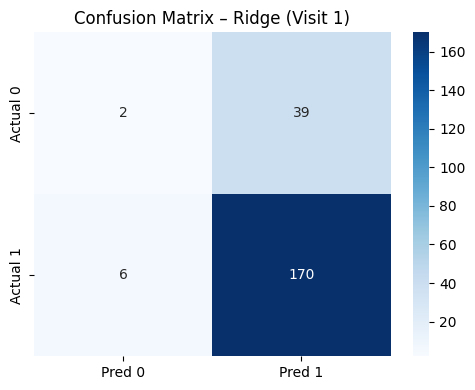

=== Top 20 Features – Ridge ===
                 feature  importance
       Treatment_present    0.486809
          voms_fogginess    0.218622
           vmst_headache    0.189030
              npc_nausea    0.170800
    saccades_vert_nausea    0.143579
 saccades_vert_dizziness    0.119466
   smoothpursuits_nausea    0.116738
      vor_vert_dizziness    0.102204
        hx_mood_disorder    0.101778
saccades_horiz_fogginess    0.096528
smoothpursuits_fogginess    0.094258
          vmst_dizziness    0.087535
smoothpursuits_dizziness    0.085604
       vor_vert_headache    0.082969
           npc_dizziness    0.079010
saccades_horiz_dizziness    0.060691
         vor_vert_nausea    0.058621
  saccades_vert_headache    0.056579
          bess_double_ec    0.052553
      vor_horiz_headache    0.049822


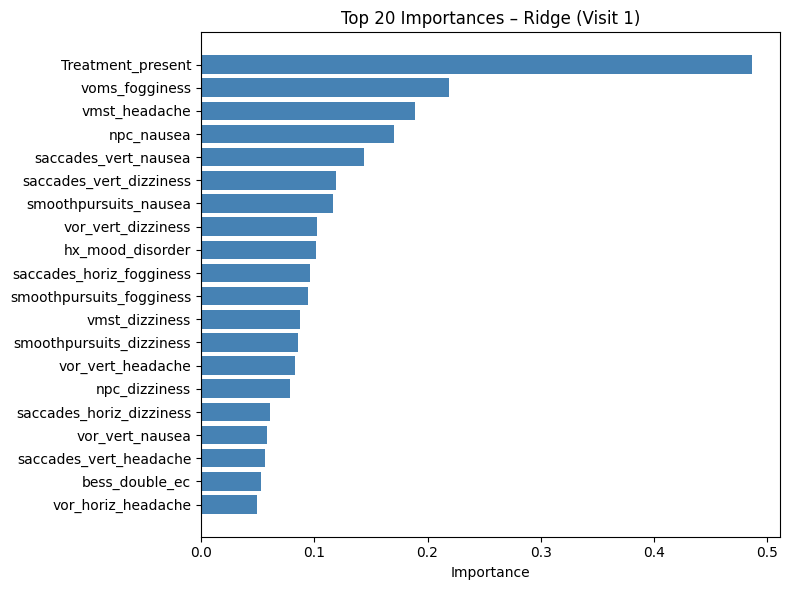

In [76]:
plot_confusion(y_true_rg, y_pred_rg, "Confusion Matrix – Ridge (Visit 1)")
fi_df_rg = (pd.DataFrame({"feature": X_rg.columns, "importance": fi_sum_rg / len(df)})
             .sort_values("importance", ascending=False))
print("=== Top 20 Features – Ridge ===")
print(fi_df_rg.head(20).to_string(index=False))
top20_rg = plot_feature_importance(fi_df_rg, "Top 20 Importances – Ridge (Visit 1)")


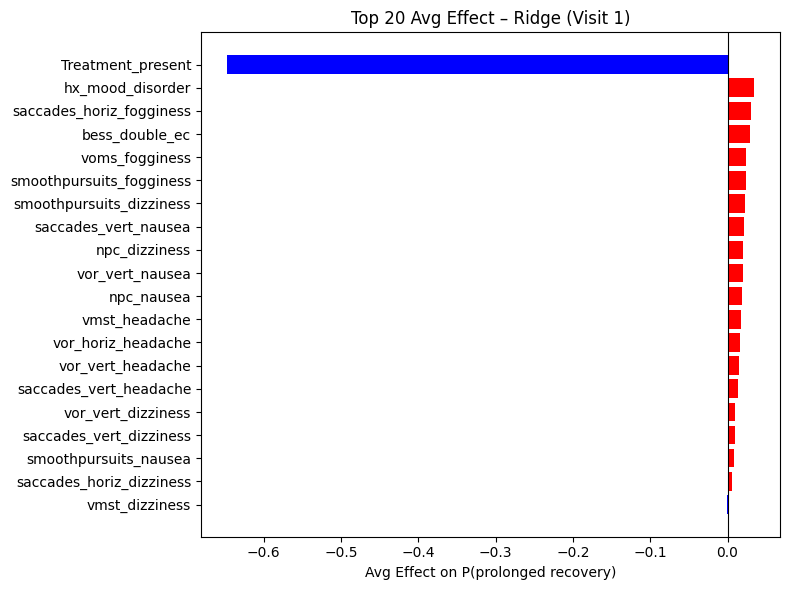

In [77]:
# Average effect plot – Ridge
# Uses sigmoid-transformed decision function as probability proxy
_m_rg = RidgeClassifier(alpha=best_alpha_rg).fit(X_rg, y_rg)

top_feats_rg = top20_rg["feature"].tolist()
effects_rg = []
for f in top_feats_rg:
    med = X_rg[f].median()
    X_hi = X_rg[X_rg[f] > med]
    X_lo = X_rg[X_rg[f] <= med]

    def dec_to_prob(X_sub):
        if X_sub.empty:
            return 0.0
        dec = _m_rg.decision_function(X_sub)
        return (1 / (1 + np.exp(-dec))).mean()

    effects_rg.append({
        "feature": f,
        "avg_effect": dec_to_prob(X_hi) - dec_to_prob(X_lo)
    })

eff_rg = pd.DataFrame(effects_rg).sort_values("avg_effect", key=abs, ascending=False)
colors = eff_rg["avg_effect"].apply(lambda v: "red" if v > 0 else "blue")
plt.figure(figsize=(8, 6))
plt.barh(eff_rg["feature"], eff_rg["avg_effect"], color=colors)
plt.xlabel("Avg Effect on P(prolonged recovery)")
plt.axvline(0, color="black", lw=0.8)
plt.title("Top 20 Avg Effect – Ridge (Visit 1)")  # change to Visit 1 as needed
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Summary Comparison Table – Visit 1 (Comment 37)

In [78]:
summary_rows = [
    ("LightGBM",       metrics_lgbm, cis_lgbm),
    ("Decision Tree",  metrics_dt,   cis_dt),
    ("Random Forest",  metrics_rf,   cis_rf),
    ("XGBoost",        metrics_xgb,  cis_xgb),
    ("SVC",            metrics_svc,  cis_svc),
    ("Ridge",          metrics_rg,   cis_rg),
]

rows = []
for name, pts, cis in summary_rows:
    row = {"Model": name}
    for k in ["accuracy", "bal_accuracy", "precision", "recall", "f1", "specificity", "mcc", "brier"]:
        if k in pts:
            lo, hi = cis[k]
            row[k] = f"{pts[k]:.3f} [{lo:.3f}, {hi:.3f}]"
        else:
            row[k] = "N/A"
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("Model")

# Use .style to create a readable, non-text based HTML table (best for Jupyter/Colab)
summary_df.style.set_caption("VISIT 1 – Model Comparison (Point Estimate [95% Bootstrap CI])")

,accuracy,bal_accuracy,precision,recall,f1,specificity,mcc,brier
Model,,,,,,,,
LightGBM,"0.816 [0.765, 0.866]","0.568 [0.510, 0.633]","0.833 [0.777, 0.882]","0.966 [0.936, 0.989]","0.895 [0.859, 0.925]","0.171 [0.054, 0.294]","0.225 [0.041, 0.391]","0.164 [0.122, 0.213]"
Decision Tree,"0.774 [0.710, 0.825]","0.608 [0.533, 0.684]","0.851 [0.792, 0.901]","0.875 [0.823, 0.918]","0.863 [0.819, 0.898]","0.341 [0.194, 0.488]","0.228 [0.070, 0.378]","0.174 [0.137, 0.214]"
Random Forest,"0.811 [0.756, 0.862]","0.500 [0.500, 0.500]","0.811 [0.756, 0.862]","1.000 [1.000, 1.000]","0.896 [0.861, 0.926]","0.000 [0.000, 0.000]","0.000 [0.000, 0.000]","0.147 [0.119, 0.180]"
XGBoost,"0.820 [0.765, 0.871]","0.581 [0.521, 0.645]","0.837 [0.781, 0.887]","0.966 [0.936, 0.989]","0.897 [0.860, 0.928]","0.195 [0.077, 0.321]","0.257 [0.076, 0.422]","0.151 [0.116, 0.192]"
SVC,"0.806 [0.751, 0.857]","0.497 [0.491, 0.500]","0.810 [0.755, 0.861]","0.994 [0.982, 1.000]","0.893 [0.858, 0.923]","0.000 [0.000, 0.000]","-0.033 [-0.062, 0.000]","0.156 [0.125, 0.192]"
Ridge,"0.793 [0.737, 0.843]","0.507 [0.477, 0.545]","0.813 [0.757, 0.865]","0.966 [0.936, 0.989]","0.883 [0.848, 0.914]","0.049 [0.000, 0.122]","0.031 [-0.093, 0.182]","0.177 [0.162, 0.194]"
